In [9]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset,ConcatDataset
import numpy as np
import pandas as pd

In [80]:
class CrudeDataset(Dataset):

    mapping = {f"ch{i}": i for i in range(8)}

    def __init__(self, path, seq_len=100):
        self.df = pd.read_csv(path)

        # Ensure correct types early
        self.df["channel"] = self.df["channel"].astype(str)

        # Pre-group for speed + stability
        self.groups = self.df.groupby("batch_id")

        # Keep only valid batch_ids (length >= 2)
        self.batch_ids = [
            bid for bid, g in self.groups
            if len(g) >= 2
        ]

        self.seq_len = seq_len

    def __len__(self):
        return len(self.batch_ids)

    def __getitem__(self, idx):
        batch_id = self.batch_ids[idx]

        # ✅ Safe group access (no copy warning)
        batch_data = self.groups.get_group(batch_id).sort_values("time").copy()

        # =========================
        # Channel mapping (SAFE)
        # =========================
        batch_data["channel"] = batch_data["channel"].map(self.mapping)

        # Fill unmapped channels (important!)
        batch_data["channel"] = batch_data["channel"].fillna(0)

        # =========================
        # TARGET (spoofed)
        # =========================
        target = torch.tensor(
            [float(batch_data.iloc[-1]["spoofed"])],
            dtype=torch.float32
        )

        # =========================
        # DROP UNUSED
        # =========================
        batch_data = batch_data.drop(columns=["spoofed", "time", "batch_id"])

        # Convert to numpy safely
        data = batch_data.to_numpy(dtype=np.float32)

        # =========================
        # SPLIT
        # =========================
        features = data[:-1]           # (T-1, F)
        transformed_target = data[-1]  # (F,)

        # =========================
        # FIX VARIABLE LENGTH (IMPORTANT)
        # =========================
        if len(features) < self.seq_len:
            pad = np.zeros((self.seq_len - len(features), features.shape[1]), dtype=np.float32)
            features = np.vstack([pad, features])
        else:
            features = features[-self.seq_len:]

        # =========================
        # TO TENSOR + CLEAN
        # =========================
        features = torch.from_numpy(features)
        transformed_target = torch.from_numpy(transformed_target)

        # Numerical safety
        features = torch.nan_to_num(features, nan=0.0, posinf=10.0, neginf=-10.0)
        transformed_target = torch.nan_to_num(transformed_target, nan=0.0, posinf=10.0, neginf=-10.0)

        # Clamp (stabilizes training)
        features = torch.clamp(features, -5.0, 5.0)
        transformed_target = torch.clamp(transformed_target, -5.0, 5.0)

        return target, features, transformed_target

In [81]:
train_base="../dataset/train/"
val_base="../dataset/val/"
train_paths=[]
val_paths=[]
for i in range(0,8):
    filename=f"ch{i}.csv"
    train_filepath=train_base+"train_"+filename
    val_filepath=val_base+"val_"+filename
    print(train_filepath)
    print(val_filepath)
    train_paths.append(train_filepath)
    val_paths.append(val_filepath)

../dataset/train/train_ch0.csv
../dataset/val/val_ch0.csv
../dataset/train/train_ch1.csv
../dataset/val/val_ch1.csv
../dataset/train/train_ch2.csv
../dataset/val/val_ch2.csv
../dataset/train/train_ch3.csv
../dataset/val/val_ch3.csv
../dataset/train/train_ch4.csv
../dataset/val/val_ch4.csv
../dataset/train/train_ch5.csv
../dataset/val/val_ch5.csv
../dataset/train/train_ch6.csv
../dataset/val/val_ch6.csv
../dataset/train/train_ch7.csv
../dataset/val/val_ch7.csv


In [82]:
combined_val_dataset = []
combined_train_dataset = []

for train_paths, val_paths in zip(train_paths, val_paths):
    train_dataset=CrudeDataset(train_paths)
    val_dataset=CrudeDataset(val_paths)
    combined_train_dataset.append(train_dataset)
    combined_val_dataset.append(val_dataset)

In [83]:
combined_val_dataset = ConcatDataset(combined_val_dataset)
combined_train_dataset = ConcatDataset(combined_train_dataset)

In [84]:
train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(combined_val_dataset, batch_size=32, shuffle=False)

In [85]:
target, features, transformed_target = next(iter(train_loader))
print("Target shape:", target.shape)  # (batch_size, 1)
print("Features shape:", features.shape)  # (batch_size, seq_len, num_features)
print("Transformed Target shape:", transformed_target.shape)  # (batch_size, num_features)

Target shape: torch.Size([32, 1])
Features shape: torch.Size([32, 100, 14])
Transformed Target shape: torch.Size([32, 14])


In [64]:
print("features:", features[0][99])

features: tensor([     0.0000,      0.0000,      0.0000,      0.0000, 174150.0625,
             0.0000,      0.0000,      0.0000,      0.0000,      0.0000,
             0.0000,      0.0000,      0.0000,      0.0000])


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=14, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1,):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
                
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
                
        # Output layers
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Prediction head
        self.output_projection = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, input_dim)
        )
        
    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape
        # Reshape for transformer
        x = x.view(batch_size , seq_len, input_dim)
        
        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        residual = x[:, -1, :]  # (batch, input_dim)

        # Apply transformer
        x = self.transformer(x)  # (batch, seq_len, d_model)
        
        # Take last timestep
        x = x[:, -1, :]  # (batch, d_model)
        
        # Reshape back
        x = x.view(batch_size, self.d_model)
        
        # Apply layer norm and residual
        x = self.layer_norm1(x+residual)
        x = self.dropout(x)
        
        # Output projection
        output = self.output_projection(x)
        
        return output


In [66]:
model_testing = TimeSeriesTransformer(input_dim=features.shape[2])


In [67]:
out=model_testing(features)

In [68]:
out.shape

torch.Size([32, 14])

In [72]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Model Parameters: 408782

Starting training...


Epoch 1/20 [Train]:   0%|          | 0/2007 [00:00<?, ?it/s]

Epoch 1/20 [Val]: 100%|██████████| 861/861 [00:31<00:00, 27.38it/s, loss=6.4] 


  ✓ Saved best market model (val_loss: 5.164986)

Epoch 1/20
  Train - Market: 6.373534
  Val   - Market: 5.164986
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 2/20 [Val]: 100%|██████████| 861/861 [00:32<00:00, 26.35it/s, loss=4.33]


...

  ✓ Saved best market model (val_loss: 3.831102)

Epoch 18/20
  Train - Market: 3.717521
  Val   - Market: 3.831102
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 19/20 [Val]: 100%|██████████| 861/861 [00:33<00:00, 25.51it/s, loss=3.89]


  ✓ Saved best market model (val_loss: 3.815597)

Epoch 19/20
  Train - Market: 3.715026
  Val   - Market: 3.815597
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 20/20 [Val]: 100%|██████████| 861/861 [00:33<00:00, 25.52it/s, loss=3.93]


  ✓ Saved best market model (val_loss: 3.810573)

Epoch 20/20
  Train - Market: 3.710412
  Val   - Market: 3.810573
  LR    - Market: 0.000100
------------------------------------------------------------

Training completed!


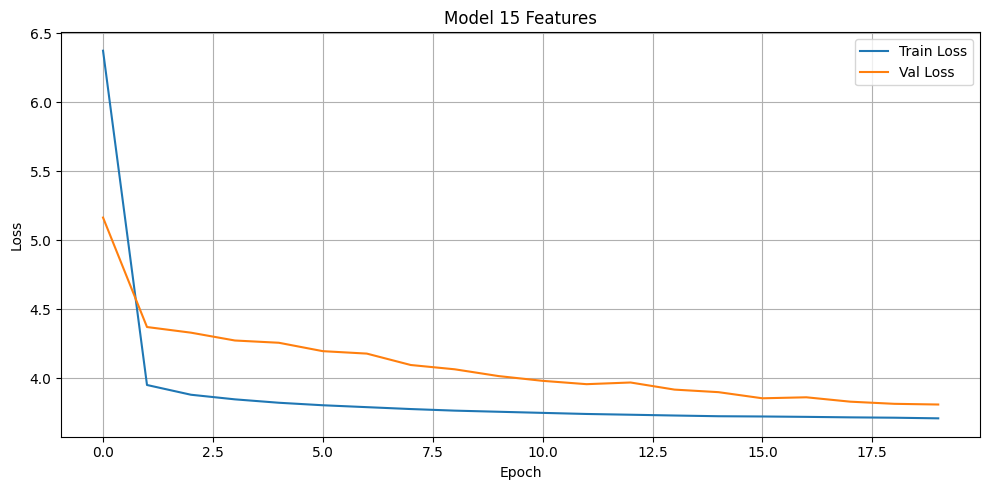

In [86]:
model=TimeSeriesTransformer(input_dim=features.shape[2]).to(device)

print("Model Parameters:", sum(p.numel() for p in model.parameters()))

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ==================== TRAINING LOOP ====================

num_epochs = 20
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for _, features, transformed_target in train_bar:
        # Move to device
        features = features.to(device)
        transformed_target = transformed_target.to(device)
        
        # Train Market Model
        optimizer.zero_grad()
        output = model(features)
        loss = criterion(output, transformed_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix({
            'loss': loss.item()
        })
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation phase
    model.eval()        
    val_loss = 0
    

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for _, features, transformed_target in val_bar:
            features = features.to(device)
            transformed_target = transformed_target.to(device)

            output = model(features)
            
            loss = criterion(output, transformed_target)
            
            val_loss += loss.item()
            
            val_bar.set_postfix({
                'loss': loss.item()
            })
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save(model.state_dict(), 'best_model_6.pth')
        print(f"  ✓ Saved best market model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train - Market: {avg_train:.6f}")
    print(f"  Val   - Market: {avg_val:.6f}")
    print(f"  LR    - Market: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 15 Features')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()


In [ ]:
class Head(nn.Module):
    def __init__(
        self,
        dim: int = 18,
        hidden_dim: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)  # (B, 1) → RAW LOGITS

Head Model Parameters: 4025
Timeseries Model Parameters: 408782

Starting training...


Epoch 1/20 [Train]:   0%|          | 0/2007 [00:00<?, ?it/s]

Epoch 1/20 [Val]: 100%|██████████| 861/861 [00:30<00:00, 27.97it/s, loss=0.657]


  ✓ Saved best market model (val_loss: 0.655750)

Epoch 1/20
  Train - Market: 0.795551
  Val   - Market: 0.655750
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 2/20 [Val]: 100%|██████████| 861/861 [00:34<00:00, 25.18it/s, loss=0.671]


...


Epoch 18/20
  Train - Market: 0.714820
  Val   - Market: 1.178594
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 19/20 [Val]: 100%|██████████| 861/861 [00:35<00:00, 24.51it/s, loss=9.74]    



Epoch 19/20
  Train - Market: 0.705933
  Val   - Market: 1.129153
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 20/20 [Val]: 100%|██████████| 861/861 [00:34<00:00, 24.98it/s, loss=10.2]    



Epoch 20/20
  Train - Market: 0.692020
  Val   - Market: 1.024206
  LR    - Market: 0.000100
------------------------------------------------------------

Training completed!


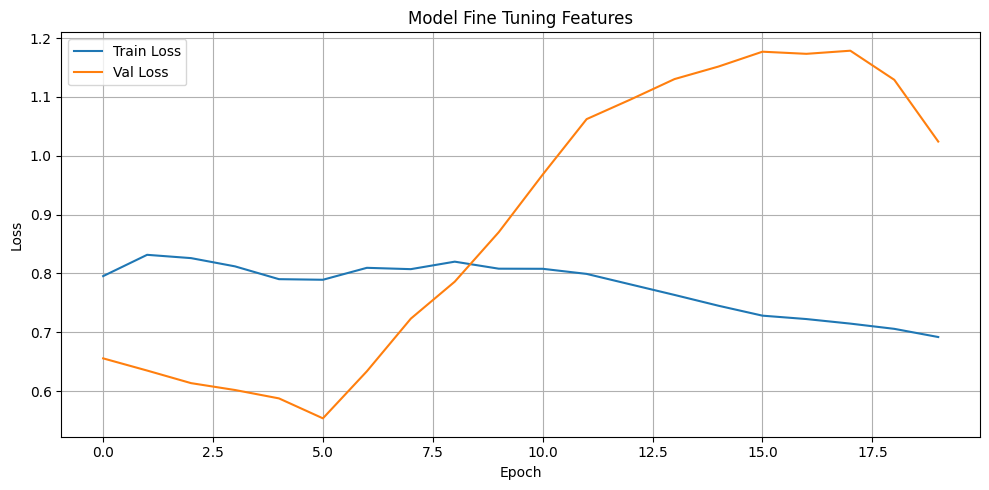

In [91]:
timeseries_model = TimeSeriesTransformer(input_dim=features.shape[2]).to(device)
timeseries_model.load_state_dict(
    torch.load('best_model_6.pth', map_location=device)
)
head_model=Head(28).to(device)    
print("Head Model Parameters:", sum(p.numel() for p in head_model.parameters()))
print("Timeseries Model Parameters:", sum(p.numel() for p in timeseries_model.parameters()))

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer = torch.optim.Adam([
            {'params': head_model.parameters(), 'lr': 0.0001},
            {'params': timeseries_model.parameters(), 'lr': 0.0001 * 0.1},  # Lower LR for pretrained
])

criterion = nn.BCEWithLogitsLoss()
# ==================== TRAINING LOOP ====================

num_epochs = 20
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    timeseries_model.train()
    head_model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for target, features, transformed_target in train_bar:
        # Move to device
        features = features.to(device)
        target = target.to(device)
        transformed_target = transformed_target.to(device)
        
        # Train Market Model
        optimizer.zero_grad()
        output = timeseries_model(features)
        fusion = torch.cat([output, transformed_target], dim=-1)
        output = head_model(fusion)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(head_model.parameters()) + list(timeseries_model.parameters()), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix({
            'loss': loss.item()
        })
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation phase
    timeseries_model.eval()
    head_model.eval()
    val_loss = 0
    

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for target, features, transformed_target in val_bar:
            features = features.to(device)
            target = target.to(device)
            transformed_target = transformed_target.to(device)

            output = timeseries_model(features)
            fusion = torch.cat([output, transformed_target], dim=-1)
            output = head_model(fusion)
            
            loss = criterion(output, target)
            
            val_loss += loss.item()
            
            val_bar.set_postfix({
                'loss': loss.item()
            })
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save({ 'head_model': head_model.state_dict(), 'timeseries_model': timeseries_model.state_dict() }, 'finetuned_with_head.pth')
        print(f"  ✓ Saved best market model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train - Market: {avg_train:.6f}")
    print(f"  Val   - Market: {avg_val:.6f}")
    print(f"  LR    - Market: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Fine Tuning Features')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_after_fine_tuning.png')
plt.show()


In [92]:
from sklearn.metrics import roc_auc_score,accuracy_score,precision_score,recall_score,f1_score,classification_report

In [93]:
timeseries_model.load_state_dict(torch.load('finetuned_with_head.pth')['timeseries_model'])
head_model.load_state_dict(torch.load('finetuned_with_head.pth')['head_model'])

y_pred_list=[]
y_true_list=[]

for target, features, transformed_target in val_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)

    output = timeseries_model(features)
    fusion = torch.cat([output, transformed_target], dim=-1)

    y_pred = head_model(fusion)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)
# If logits → apply sigmoid
y_pred_prob = 1 / (1 + np.exp(-y_pred))  # sigmoid

# Convert to class labels
y_pred_label = (y_pred_prob > 0.5).astype(int)
y_pred_label = y_pred_label.reshape(-1)
y_pred_prob  = y_pred_prob.reshape(-1)
y_true       = y_true.reshape(-1)
print("Accuracy:", accuracy_score(y_true, y_pred_label))
print("Precision:", precision_score(y_true, y_pred_label))
print("Recall:", recall_score(y_true, y_pred_label))
print("F1 Score:", f1_score(y_true, y_pred_label))

# ROC-AUC uses probabilities, NOT labels
print("ROC-AUC:", roc_auc_score(y_true, y_pred_prob))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_label))

Accuracy: 0.7154220543367718
Precision: 0.7654166293743847
Recall: 0.6212407380502688
F1 Score: 0.6858334335779301
ROC-AUC: 0.7967134129700996

Classification Report:

              precision    recall  f1-score   support

         0.0       0.68      0.81      0.74     13766
         1.0       0.77      0.62      0.69     13766

    accuracy                           0.72     27532
   macro avg       0.72      0.72      0.71     27532
weighted avg       0.72      0.72      0.71     27532



In [94]:
timeseries_model.eval()

X_list = []
y_list = []

with torch.no_grad():
    for target, features, transformed_target in val_loader:

        features = features.to(device)

        # Extract representation
        ts_output = timeseries_model(features)   # (B, 15)

        # Choose fusion strategy
        fusion = torch.cat([ts_output, transformed_target.to(device)], dim=-1)  # (B, 28)
        # Move to CPU numpy
        X_list.append(fusion.cpu().numpy())
        y_list.append(target.numpy())

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0).reshape(-1)

print("Feature shape:", X.shape)  # (N, 15)
print("Target shape:", y.shape)

Feature shape: (27532, 28)
Target shape: (27532,)


In [95]:
timeseries_model.eval()

X_list_tr = []
y_list_tr = []

with torch.no_grad():
    for target, features, transformed_target in train_loader:

        features = features.to(device)

        # Extract representation
        ts_output = timeseries_model(features)   # (B, 15)

        # Choose fusion strategy
        fusion = torch.cat([ts_output, transformed_target.to(device)], dim=-1)  # (B, 28)
        # Move to CPU numpy
        X_list_tr.append(fusion.cpu().numpy())
        y_list_tr.append(target.numpy())

X_list_tr = np.concatenate(X_list_tr, axis=0)
y_list_tr = np.concatenate(y_list_tr, axis=0).reshape(-1)

print("Feature shape:", X_list_tr.shape)  # (N, 15)
print("Target shape:", y_list_tr.shape)

Feature shape: (64214, 28)
Target shape: (64214,)


In [96]:
from xgboost import XGBClassifier

In [97]:
model_xgb = XGBClassifier()
model_xgb.fit(X_list_tr, y_list_tr)
y_pred_xgb = model_xgb.predict(X)
print("XGBoost Accuracy:", accuracy_score(y, y_pred_xgb))
print("XGBoost Precision:", precision_score(y, y_pred_xgb))
print("XGBoost Recall:", recall_score(y, y_pred_xgb))   
print("XGBoost F1 Score:", f1_score(y, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y, model_xgb.predict_proba(X)[:, 1]) )

print("\nXGBoost Classification Report:\n")
print(classification_report(y, y_pred_xgb))


XGBoost Accuracy: 0.7296600319628069
XGBoost Precision: 0.7443388206198315
XGBoost Recall: 0.6996222577364521
XGBoost F1 Score: 0.7212881482868376
XGBoost ROC-AUC: 0.8439307236249377

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74     13766
         1.0       0.74      0.70      0.72     13766

    accuracy                           0.73     27532
   macro avg       0.73      0.73      0.73     27532
weighted avg       0.73      0.73      0.73     27532

